In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve

In [3]:
Data= pd.read_csv(r"C:\Users\Harsh\OneDrive\Desktop\DATASETS\100D_heart_disease_dataset.csv")

In [5]:
Data.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [6]:
Test_Data = pd.read_csv(r"C:\Users\Harsh\OneDrive\Desktop\DATASETS\100D_test_dataset.csv")

In [7]:
X_test = Test_Data.drop("target", axis=1)
y_test = Test_Data["target"]

In [8]:
X_train = Data.drop("target", axis=1)
y_train = Data["target"]

In [9]:
model = DecisionTreeClassifier(criterion='gini',max_depth=5,min_samples_split=10,random_state=42)

In [10]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)

In [11]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [24]:
y_pred,y_z

(array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
        1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,
        1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
        0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1], dtype=int64),
 array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.97222222, 0.        , 0.        , 0.        , 0.        ,
        0.97222222, 0.        , 0.97222222, 0.        , 0.375     ,
        0.97222222, 0.97222222, 0.5       , 0.97222222, 0.97222222,
        0.        , 0.57142857, 1.        , 0.97222222, 0.97222222,
        0.        , 0.375     , 0.57142857, 0.375     , 0.        ,
        0.        , 0.97222222, 0.        , 0.        , 0.97222222,
        0.        , 0.375     , 0.97222222, 0.5       , 0.5       ,
        0.5       , 0.5       , 0.97222222, 0.        , 0.97222222,
        0.97222222, 0.97222222, 0

In [12]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

In [17]:
results = {"Accuracy": acc, "Precision": prec, "Recall": rec, "AUC": auc, "fpr_tpr": roc_curve(y_test, y_prob)}

In [15]:
results

{'Accuracy': 0.89,
 'Precision': 0.9090909090909091,
 'Recall': 0.851063829787234,
 'AUC': 0.9666800481734243,
 'fpr_tpr': (array([0.        , 0.        , 0.01886792, 0.0754717 , 0.1509434 ,
         0.24528302, 1.        ]),
  array([0.        , 0.0212766 , 0.76595745, 0.85106383, 0.93617021,
         1.        , 1.        ]),
  array([       inf, 1.        , 0.97222222, 0.57142857, 0.5       ,
         0.375     , 0.        ]))}

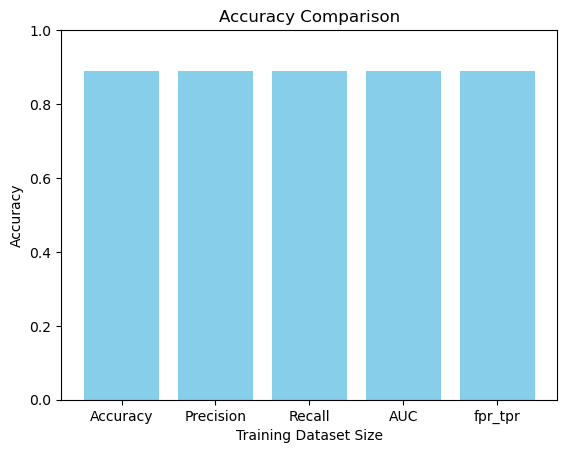

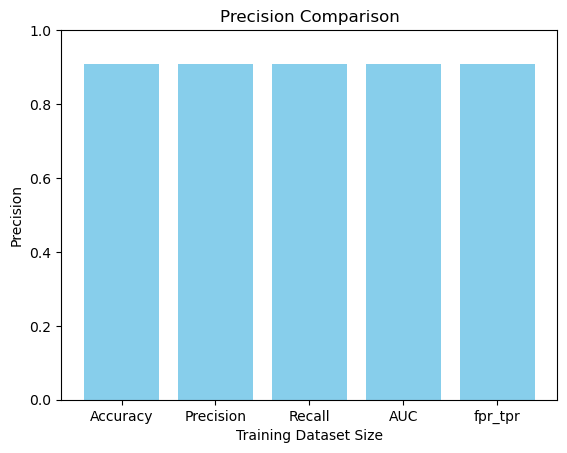

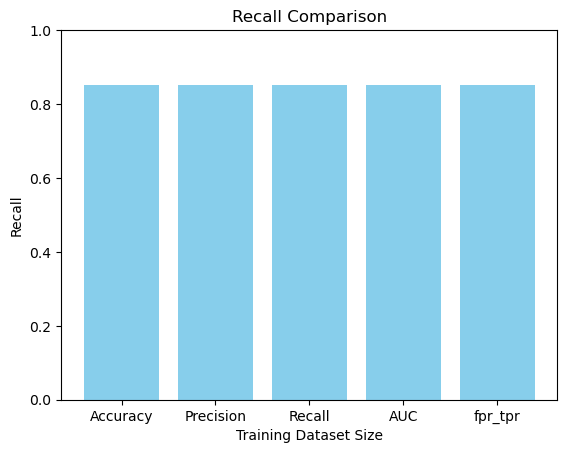

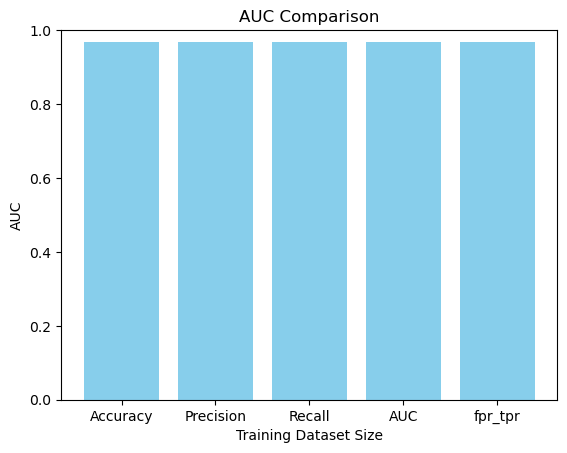

In [19]:
metrics = ["Accuracy", "Precision", "Recall", "AUC"]
for metric in metrics:
    plt.figure()
    plt.bar(results.keys(), [results[metric] for size in results], color="skyblue")
    plt.title(f"{metric} Comparison")
    plt.ylabel(metric)
    plt.xlabel("Training Dataset Size")
    plt.ylim(0, 1)
    plt.show()

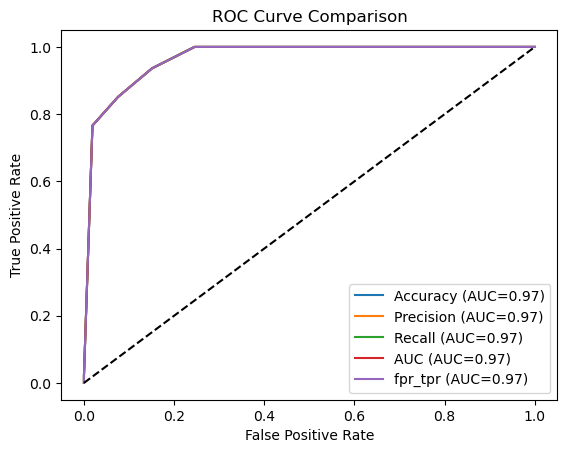

In [22]:
plt.figure()
for size in results:
    fpr, tpr, _ = results["fpr_tpr"]
    plt.plot(fpr, tpr, label=f"{size} (AUC={results['AUC']:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [29]:
pip install tree


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Obtaining dependency information for svgwrite from https://files.pythonhosted.org/packages/84/15/640e399579024a6875918839454025bb1d5f850bb70d96a11eabb644d11c/svgwrite-1.4.3-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/67.1 kB ? eta -:--:--
   ------------------ --------------------- 30.7/67.1 kB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 67.1/67.1 kB 720.0 kB/s eta 0:00:00
  Created wheel for tree: filename=Tree-0.2.4-py3-none-any.whl size=7878 sha256=64f4e9e8cb0cb4ba1578fe9309fbd266a4d8378fdba5a01958ac50b8c53b78e0
  Stored in directory: c:\users\harsh\appdata\local\pip\cache\wheels\e8\ed\fe\b4c6a9b7a5b8df6d966ea673e26a46a7451b020af754eafa6b
Successfully built tree
Note: you may need to restart the kernel to use updated packages.


In [32]:
from sklearn import tree

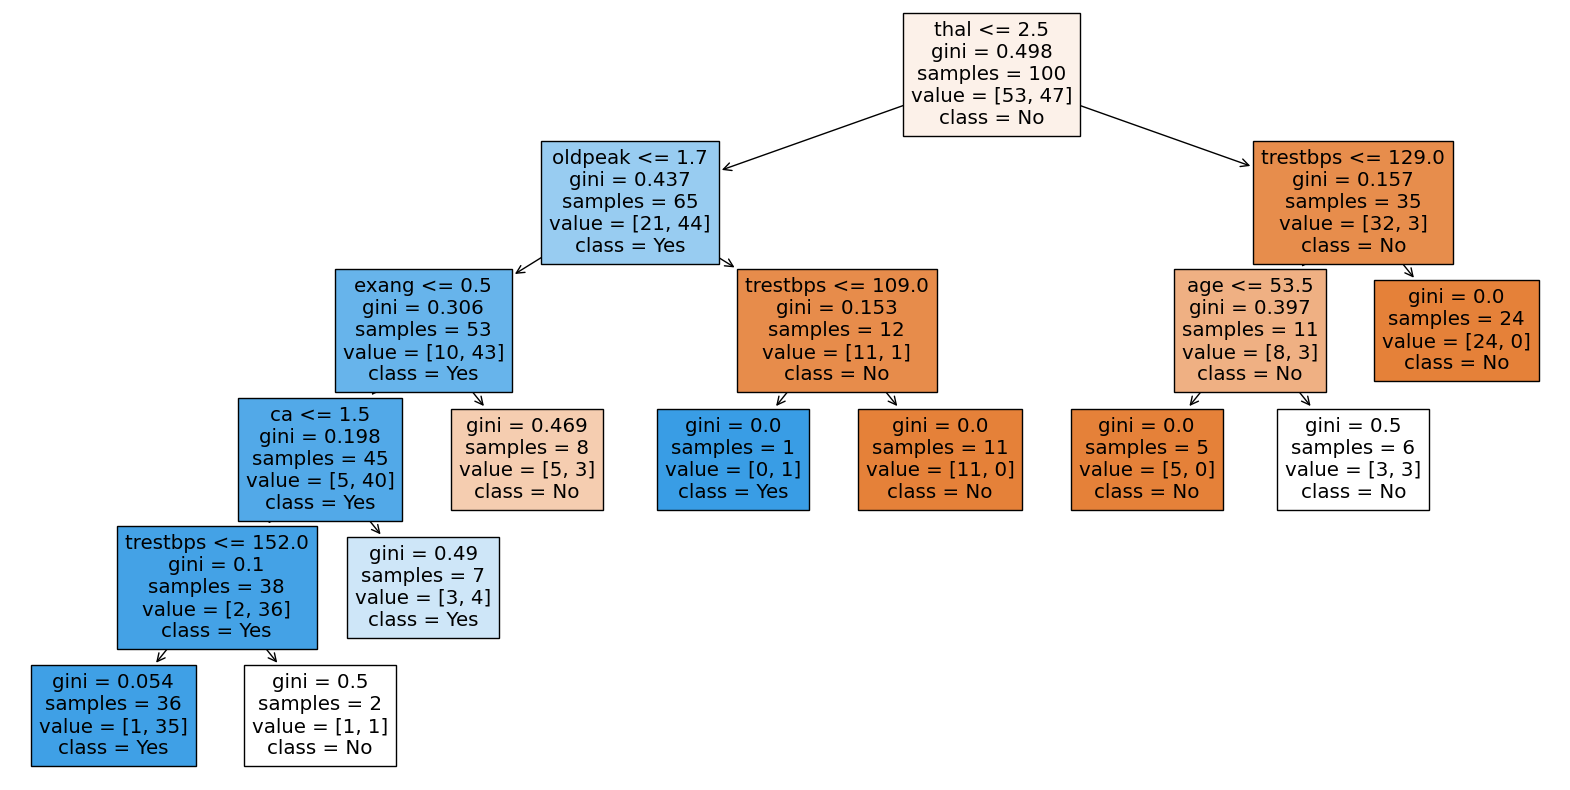

In [34]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=X_train.columns.tolist(),  
    class_names=["No", "Yes"],               
    filled=True
)
plt.show()